# Bell's Theorem Quantum Computing Tutorial
First we are going to import all our packages and define all our functions. This code might look complicated, but don't worry about the syntax / functionality of these functions -- we will explain what all these functions do as we walk through the experiment.

In [1]:
# import packages
import numpy as np

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator

from matplotlib import pyplot as plt
from matplotlib import ticker as tck

In [2]:
def backend_setup(token, instance, min_num_qubits):
    if not isinstance(token, str):
        raise ValueError(f"Token must be a string, got: {token}")
    if not isinstance(instance, str):
        raise ValueError(f"Instance must be a string, got: {instance}")
    if not isinstance(min_num_qubits, int) or min_num_qubits < 1:
        raise ValueError(f"Minimum qubit number must be a positive integer, got: {min_num_qubits}")
    QiskitRuntimeService.save_account(token = token, instance = instance, overwrite = True)
    service = QiskitRuntimeService()
    backend = service.least_busy(operational = True, simulator = False, min_num_qubits = min_num_qubits)
    print(backend.name)
    return backend

In [3]:
def setup_chsh_circuit():
    theta = Parameter('$\\theta$')
    chsh_circuit = QuantumCircuit(2)
    chsh_circuit.h(0)
    chsh_circuit.cx(0,1)
    chsh_circuit.ry(theta,0)
    return chsh_circuit

In [4]:
def make_phases(number_of_phases):
    if not isinstance(number_of_phases, int) or number_of_phases < 1:
        raise ValueError(f"Number of phases must be a positive integer, got: {number_of_phases}")
    phases = np.linspace(0, 2 * np.pi, number_of_phases)
    individual_phases = [[ph] for ph in phases]
    return phases, individual_phases

In [5]:
def make_observables(state1, state2, state3, state4):
    if not isinstance(state1, str) or not isinstance(state2, str) or not isinstance(state3, str) or not isinstance(state4, str):
        raise ValueError("At least one of your states is not a string -- they must all be strings!")
    observable1 = SparsePauliOp.from_list([(state1, 1), (state2, -1), (state3, 1), (state4, 1)])
    observable2 = SparsePauliOp.from_list([(state1, 1), (state2, 1), (state3, -1), (state4, 1)])
    return observable1, observable2

In [6]:
def make_isa_circuit(chsh_circuit, backend, optimization_level):
    if not isinstance(optimization_level, int):
        raise ValueError(f"Optimization level must be an integer, got: {optimization_level}")
    target = backend.target
    pm = generate_preset_pass_manager(target = target, optimization_level = optimization_level)
    chsh_isa_circuit = pm.run(chsh_circuit)
    return chsh_isa_circuit

In [7]:
def isa_observables(observable1, observable2, chsh_isa_circuit):
    isa_observable1 = observable1.apply_layout(layout = chsh_isa_circuit.layout)
    isa_observable2 = observable2.apply_layout(layout = chsh_isa_circuit.layout)
    return isa_observable1, isa_observable2

In [8]:
def collect_data(backend, chsh_isa_circuit, isa_observable1, isa_observable2, individual_phases):
    estimator = Estimator(mode = backend)
    pub = (
        chsh_isa_circuit,
        [[isa_observable1], [isa_observable2]],
        individual_phases,
    )

    job_result = estimator.run(pubs = [pub]).result()

    chsh1_est = job_result[0].data.evs[0]
    chsh2_est = job_result[0].data.evs[1]

    return chsh1_est, chsh2_est

In [9]:
def plot_results(phases, chsh1_est, chsh2_est):
    fig, ax = plt.subplots(figsize = (10,6))

    # results from hardware
    ax.plot(phases / np.pi, chsh1_est, "o-", label = "CHSH1", zorder = 3)
    ax.plot(phases / np.pi, chsh2_est, "o-", label = "CHSH2", zorder = 3)

    # classical bound
    ax.axhline(y = 2, color = "0.9", linestyle = "--")
    ax.axhline(y = -2, color = "0.9", linestyle = "--")

    # quantum bound
    ax.axhline(y = np.sqrt(2) * 2, color = "0.9", linestyle = "-.")
    ax.axhline(y = -np.sqrt(2) * 2, color = "0.9", linestyle = "-.")
    ax.fill_between(phases / np.pi, 2, 2 * np.sqrt(2), color = "0.6", alpha = 0.7)
    ax.fill_between(phases / np.pi, -2, -2 * np.sqrt(2), color = "0.6", alpha = 0.7)

    # labels and legend
    plt.xlabel("Theta")
    plt.ylabel("CHSH witness")
    plt.legend()
    plt.show()

(BTW: all this code below is in the package itself callable with the main() function -- we are just breaking it down into smaller functions here to better understand how the package works.)

### Step 1: Set up backend
Here, my token and instance are taken from an account I made on the IBM quantum platform. For this experiment, it is recommended we use a machine with at least 127 qubits, so we will pass these arguments into our backend_setup function. This establishes connectivity with IBM's hardware. As you can see, we return the machine that will be used for this experiment (ibm_fez)!

In [10]:
my_token = "itd8Yf4W2boZsNpZnn7rfPXs7L7z8AhSigm9ZYdAEcIN"
my_instance = "crn:v1:bluemix:public:quantum-computing:us-east:a/8291768cb13d4fcb8bee320022d597e8:e1752a2c-f2bc-4054-adc5-ac56c0b76a1e::"
my_min_num_qubits = 127

backend = backend_setup(my_token, my_instance, my_min_num_qubits)

ibm_marrakesh


### Step 2: Make CHSH circuit
All we have to do is call the setup_chsh_circuit function to make the circuit that we will be using for this experiment. It gets returned in the function, but if we want to see it, we have to call "draw", as done below, and then we see this lovely diagram of our circuit!

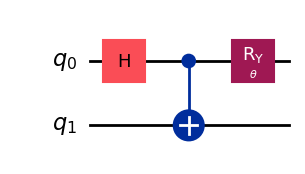

In [11]:
chsh_circuit = setup_chsh_circuit()
chsh_circuit.draw(output = "mpl", idle_wires = False, style = "iqp")

### Step 3: Make phases
This function generates a linearly spaced array (as well as a list of the same values) of phases from 0 to $2\pi$. We save these in the variables "phases" and individual_phases".

In [12]:
phases, individual_phases = make_phases(21)

### Step 4: Make CHSH observables
The make_observables function takes in 3 arguments of the states that we will be measuring, and returns the 2 observables we will be measuring and sending to the IBM hardware.

In [13]:
observable1, observable2 = make_observables("ZZ", "ZX", "XZ", "XX")

### Step 5: Make ISA compatible
In order to actually send the circuit to IBM hardware, it has to follow certain standards known as Instruction Set Architecture (ISA). This function takes in our already-made CHSH circuit, the machine we will be using, and our desired optimization level, and returns a circuit with the same functionality as our original CHSH circuit that also obeys ISA. Once again, the circuit is stored in the variable chsh_isa_circuit, but if we want to see a diagram, we have to draw it using the draw command below.

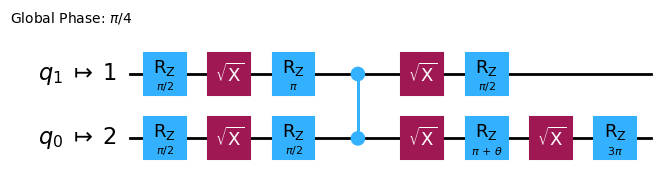

In [14]:
chsh_isa_circuit = make_isa_circuit(chsh_circuit, backend, 3)
chsh_isa_circuit.draw(output = "mpl", idle_wires = False, style = "iqp")

### Step 6: Do the same thing to the observables
One more step before we collect data: we have to put the observables in IBM format too. This function takes in the 2 observables and the ISA circuit as a reference for layout, and returns updated two corresponding ISA observables.

In [15]:
isa_observable1, isa_observable2 = isa_observables(observable1, observable2, chsh_isa_circuit)

### Step 7: Collect data!
This code is what actually sends the code to the machine and collects data. We use the collect_data function, which takes in our IBM hardware, our ISA circuit and observables, and our list of phases, and it returns an array of both CHSH quantities across the sweep.

In [ ]:
chsh1_est, chsh2_est = collect_data(backend, chsh_isa_circuit, isa_observable1, isa_observable2, individual_phases)

### Step 8: Plot results!
The plot_results function takes in our array of phases as well as our measured values for CHSH1 and CHSH2, and plots them while denoting the quantum and classical bounds in gray. Since we have data in the gray zone, we have violated the CHSH Inequality and proven Bell's Theorem!!

In [ ]:
plot_results(phases, chsh1_est, chsh2_est)